# Handling Erroneous and Missing Data

**Notebook 3: Cleaning Data Before Machine Learning**

> **Lecturer version:** This copy contains completed code and sample reference answers for teaching use. Students should receive the scaffolded version instead.


## What you will learn

Real datasets are rarely perfect. Before using data for analysis or machine learning, we must check whether the data contains wrong values, unusual values, or missing values.

By the end of this notebook, you should be able to:

- explain the difference between erroneous data, outliers, and missing data
- identify impossible or unrealistic values
- remove erroneous rows from a dataset
- use `.head()`, `.info()`, and `.describe()` to check data quality
- remove missing values using `.dropna()`
- fill missing values using `.fillna()`
- explain why data cleaning is important before machine learning

## Quick idea

| Situation | Meaning | Example | Possible action |
|---|---|---|---|
| Erroneous data | A value that is wrong or impossible | score = 175 out of 100 | remove or correct it |
| Outlier | A rare value that may still be valid | very expensive game | investigate before removing |
| Missing data | A value that was not recorded | blank study hours | remove or fill it |

> **Tip:** Do not remove data blindly. First ask: “Is this value impossible, missing, or just unusual?”

## 0. Setup

Import the required libraries at the start of the notebook.

We will use:

- `pandas` for DataFrames
- `numpy` for missing value examples using `np.nan`
- `matplotlib.pyplot` for plotting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Erroneous data

Erroneous data refers to data that was collected or entered wrongly.

For example, if a dataset contains the number of rooms in a house, negative values are impossible. A house cannot have `-3` rooms, so that value is erroneous.

However, not every unusual value is wrong. A mansion may have many rooms. That value is rare, but still possible. This type of value may be an **outlier** rather than an error.

## 1.1 Price of computer games

Imagine we are studying whether the price of a computer game is related to the number of people who like the game.

The dataset contains:

- `game_name`: name of the game
- `game_price`: price of the game in USD
- `num_people`: number of people who liked the game

Run the code below and observe the plot carefully.

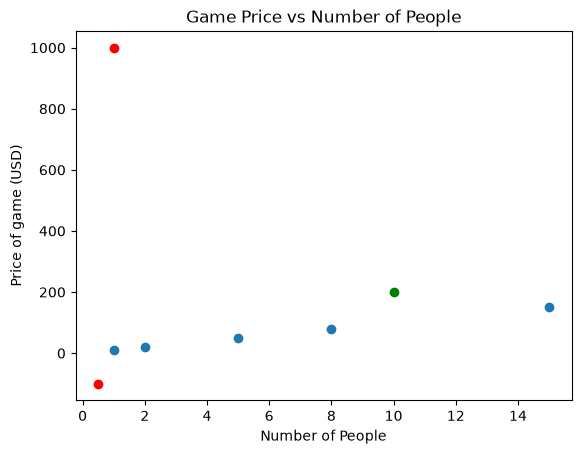

In [2]:
# game_name refers to the name of the games
# game_price refers to the price of the computer game
# num_people refers to the number of people who liked a game

game_name = ["Phone of duty", "PIFA soccer", "Lario cart", "Hokemon", "Loom", "League of failures", "Fritnite", "Fatty Trotter"]
game_price = [10, 20, 50, 150, 80, 200, 1000, -100]
num_people = [1, 2, 5, 15, 8, 10, 1, 0.5]

plt.scatter(num_people[0:5], game_price[0:5])
plt.scatter(num_people[5], game_price[5], c="g")
plt.scatter(num_people[6:8], game_price[6:8], c="r")

plt.xlabel("Number of People")
plt.ylabel("Price of game (USD)")
plt.title("Game Price vs Number of People")
plt.show()

### Observation

The points in red are likely to be erroneous data:

- One game has a negative price. A game cannot be sold at a negative price.
- One game has `0.5` people liking it. The number of people should be a whole number.
- One game costs `1000 USD`, which is unrealistic for this scenario.

The green point looks unusual, but it may still be possible. It is likely to be an **outlier**, not an error.

Now copy and edit the code so that the erroneous red data points are removed.

> **Checkpoint:** Your new plot should have no negative game price and no fraction for the number of people.

**Bonus:** Can you name the games that are erroneous?

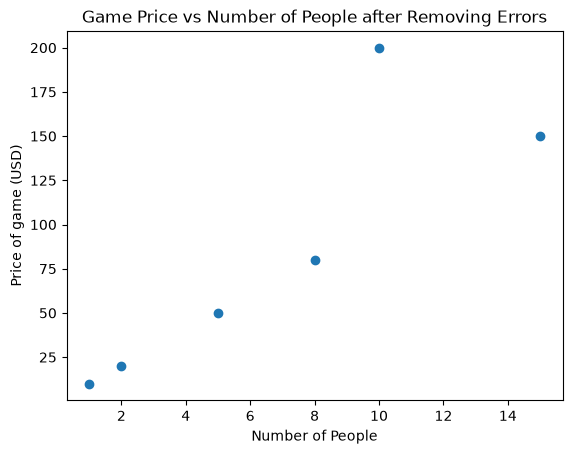

In [3]:
# Remove the erroneous data points and plot again.
# Hint: use only the valid list positions.

valid_game_name = game_name[0:6]      # edit this if needed
valid_game_price = game_price[0:6]    # edit this if needed
valid_num_people = num_people[0:6]    # edit this if needed

plt.scatter(valid_num_people, valid_game_price)
plt.xlabel("Number of People")
plt.ylabel("Price of game (USD)")
plt.title("Game Price vs Number of People after Removing Errors")
plt.show()

# Bonus answer: The erroneous games are ...

After removing the erroneous data, the relationship should look clearer.

However, there is still one point that does not seem to fit the main pattern. The green point is likely to be an **outlier**.

An outlier is not always wrong. It may simply be a rare but valid case. In this example, we will remove the outlier to see the clearer relationship.

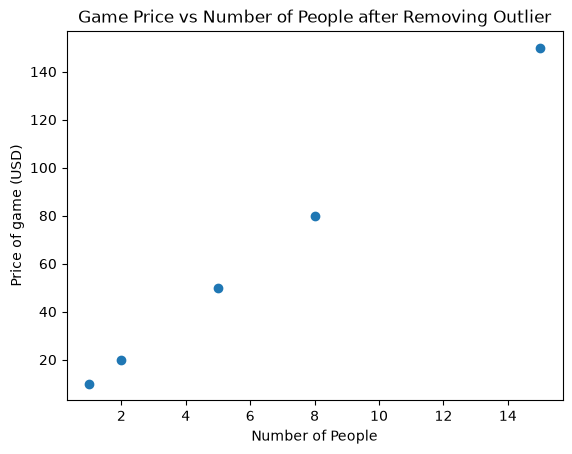

In [4]:
# Remove the outlier and plot again.
# Hint: the outlier is the green point from the earlier plot.

clean_game_name = valid_game_name[0:5]      # edit this if needed
clean_game_price = valid_game_price[0:5]    # edit this if needed
clean_num_people = valid_num_people[0:5]    # edit this if needed

plt.scatter(clean_num_people, clean_game_price)
plt.xlabel("Number of People")
plt.ylabel("Price of game (USD)")
plt.title("Game Price vs Number of People after Removing Outlier")
plt.show()

You should now see a more obvious increasing relationship: as the number of people increases, the game price also increases.

## 1.2 Handling erroneous data in DataFrames

Now we will clean erroneous data in a CSV file called `Students_Score1.csv`.

The dataset contains:

- student number
- hours spent studying in a day
- Mathematics score
- English score
- Science score

Assumptions for this activity:

- A student cannot study fewer than 0 hours in a day.
- A student is not expected to study more than 16 hours in a day.
- Exam scores should be between 0 and 100.
- If an error is found in a row, the whole row should be removed.

> **Goal:** Identify and remove rows with erroneous data.

First, load the data as a DataFrame called `df`.

In [5]:
df = pd.read_csv("./data/Students_Score1.csv")
df.head()

,Student No.,Hours spent studying in a day,Mathematics score,English score,Science score
0,1,11,44,39.6,35.2
1,2,19,76,68.4,60.8
2,3,4,16,14.4,12.8
3,4,24,96,86.4,76.8
4,5,4,16,14.4,12.8


Print the headers, first 5 rows, and `.info()` output. This helps us understand the column names and check whether there are missing values.

In [6]:
print(df.columns)
print(df.head())
df.info()

Index(['Student No.', 'Hours spent studying in a day', 'Mathematics score',
       'English score', 'Science score'],
      dtype='str')
   Student No.  Hours spent studying in a day  Mathematics score  \
0            1                             11                 44   
1            2                             19                 76   
2            3                              4                 16   
3            4                             24                 96   
4            5                              4                 16   

   English score  Science score  
0           39.6           35.2  
1           68.4           60.8  
2           14.4           12.8  
3           86.4           76.8  
4           14.4           12.8  
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    2

Next, use `.describe()` to check the minimum and maximum values. This helps us spot impossible or unrealistic values.

In [7]:
df.describe()

,Student No.,Hours spent studying in a day,Mathematics score,English score,Science score
count,267.000000,267.000000,267.000000,267.000000,267.000000
mean,134.000000,12.123596,48.749064,43.539326,38.795506
std,77.220464,7.668636,31.802503,28.521820,24.539635
min,1.000000,-10.000000,-40.000000,-36.000000,-32.000000
25%,67.500000,6.000000,24.000000,21.600000,19.200000
50%,134.000000,12.000000,48.000000,43.200000,38.400000
75%,200.500000,18.000000,74.000000,66.600000,57.600000
max,267.000000,40.000000,175.000000,144.000000,128.000000


From the minimum and maximum values, identify which columns contain erroneous data.

> **Hint:** Scores should be from 0 to 100. Hours should be from 0 to 16.

In [8]:
# Reference answer:
# The columns with erroneous values are:
# - Hours spent studying in a day: values below 0 and above 16
# - Mathematics score: values below 0 and above 100
# - English score: values below 0 and above 100
# - Science score: values below 0 and above 100


Let us first remove erroneous rows from the `Mathematics score` column.

The code below keeps only rows where the Mathematics score is between 0 and 100.

In [9]:
df2 = df[df["Mathematics score"] >= 0]
df3 = df2[df2["Mathematics score"] <= 100]

print(df3.describe())
print(df3.info())

       Student No.  Hours spent studying in a day  Mathematics score  \
count   261.000000                     261.000000         261.000000   
mean    135.578544                      12.160920          48.337165   
std      77.120975                       7.442405          29.021102   
min       1.000000                       0.000000           0.000000   
25%      70.000000                       6.000000          24.000000   
50%     137.000000                      12.000000          48.000000   
75%     202.000000                      18.000000          72.000000   
max     267.000000                      40.000000          96.000000   

       English score  Science score  
count     261.000000     261.000000  
mean       43.671264      38.914943  
std        27.756135      23.815696  
min       -15.000000       0.000000  
25%        21.600000      19.200000  
50%        43.200000      38.400000  
75%        64.800000      57.600000  
max       144.000000     128.000000  
<class 'p

Compare the information before and after removing Mathematics score errors. What do you notice?

In [10]:
# Reference answer:
# The Mathematics score minimum and maximum are now within 0 to 100.
# The row count decreases because rows with erroneous Mathematics scores were removed.


You should see that the Mathematics score now ranges from 0 to 96. The number of data points also reduces, which means some erroneous rows were removed.

Now it is your turn to remove erroneous data from:

- `English score`
- `Science score`
- `Hours spent studying in a day`

Print the final `.describe()` and `.info()` outputs.

> **Hint:** You can continue filtering from the cleaned dataframe step by step.

In [11]:
# Continue cleaning from df3
# Remove English score errors
df4 = df3[df3["English score"] >= 0]
df5 = df4[df4["English score"] <= 100]

# Remove Science score errors
df6 = df5[df5["Science score"] >= 0]
df7 = df6[df6["Science score"] <= 100]

# Remove Hours spent studying errors
df8 = df7[df7["Hours spent studying in a day"] >= 0]
df_clean = df8[df8["Hours spent studying in a day"] <= 16]

print(df_clean.describe())
print(df_clean.info())

       Student No.  Hours spent studying in a day  Mathematics score  \
count   179.000000                     179.000000         179.000000   
mean    133.536313                       8.189944          32.759777   
std      77.929762                       4.990745          19.962981   
min       1.000000                       0.000000           0.000000   
25%      63.500000                       4.000000          16.000000   
50%     138.000000                       8.000000          32.000000   
75%     199.000000                      12.500000          50.000000   
max     266.000000                      16.000000          64.000000   

       English score  Science score  
count     179.000000     179.000000  
mean       29.483799      26.207821  
std        17.966683      15.970385  
min         0.000000       0.000000  
25%        14.400000      12.800000  
50%        28.800000      25.600000  
75%        45.000000      40.000000  
max        57.600000      51.200000  
<class 'p

From the final `.describe()` output, answer the questions below:

1. How many rows remain after cleaning?
2. How many rows were removed in total?
3. What are the correct minimum and maximum scores for each subject?

In [12]:
# Reference answers:
# 1. Rows remaining: 179
# 2. Rows removed: 88 rows removed from the original 267 rows
# 3. Correct ranges after cleaning:
#    Hours spent studying in a day: 0 to 16
#    Mathematics score: 0 to 64
#    English score: 0 to 57.6
#    Science score: 0 to 51.2


## 2. Missing data

Missing data refers to gaps in a dataset. A value may be missing because:

- the data was not collected
- the person forgot to enter it
- a survey form was incomplete
- a sensor or system failed

Before analysis or machine learning, we need to decide how to handle missing data.

Think about the scenarios below. Why might there be missing data?

- Number of hours a teacher spends in school each day
- Number of phone calls an office worker receives on a mobile phone in a day
- Air temperature of your city

In [13]:
# Reference answers:
# Teacher hours: missing because teacher was on leave, timetable not recorded, or data entry was forgotten.
# Phone calls: missing because phone logs were deleted, phone was off, or calls were not recorded.
# Air temperature: missing because the sensor failed, station was offline, or data transmission failed.


Missing data can appear in different forms. In Pandas, missing values are often shown as `NaN`.

Some datasets use special numbers to represent missing data. For example, weather datasets may use `-9999` to mean that a value is missing.

In this notebook, we will mainly work with `NaN`.

## 2.1 House prices

You and your friend Ben are studying whether house prices are related to the number of rooms. Ben collected the data, but some values are missing.

Run the code below and observe the output carefully. Make sure `numpy` was imported as `np` in the setup section.

In [14]:
House_prices = [10050, 42300, 50206, np.nan, 105000, np.nan, 22350]
Num_rooms = [np.nan, 4, 5, 6, 10, 12, 2]

print("Total number of data points in House_prices =", np.count_nonzero(~np.isnan(House_prices)))
print("Total number of data points in Num_rooms =", np.count_nonzero(~np.isnan(Num_rooms)))

Total number of data points in House_prices = 5
Total number of data points in Num_rooms = 6


Why are the number of data points in `House_prices` and `Num_rooms` different? How many houses are there in total?

In [15]:
# Reference answer:
# The counts are different because some values are missing in House_prices and Num_rooms.
# There are 7 houses in total because each list has 7 positions/records.


Remove the missing data and plot the scatter plot.

Important rule: if one value is missing, remove the corresponding value from the other list too.

For example, if a house price is missing, the corresponding number of rooms must also be removed. Otherwise, the two lists will no longer match correctly.

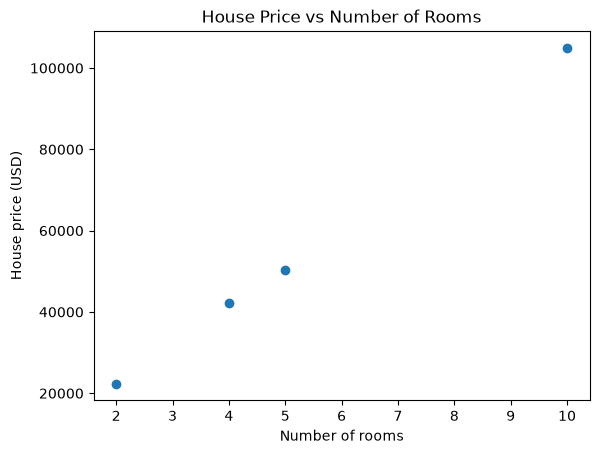

In [16]:
clean_prices = []
clean_rooms = []

for price, rooms in zip(House_prices, Num_rooms):
    if not np.isnan(price) and not np.isnan(rooms):
        clean_prices.append(price)
        clean_rooms.append(rooms)

plt.scatter(clean_rooms, clean_prices)
plt.xlabel("Number of rooms")
plt.ylabel("House price (USD)")
plt.title("House Price vs Number of Rooms")
plt.show()

# Reference observation:
# The scatter plot suggests that houses with more rooms generally have higher prices,
# but there are only a few complete data points, so we should be careful with conclusions.

**Bonus:** Can you guess suitable values for the missing values? Replace the missing values with your guesses and plot the scatter plot again.

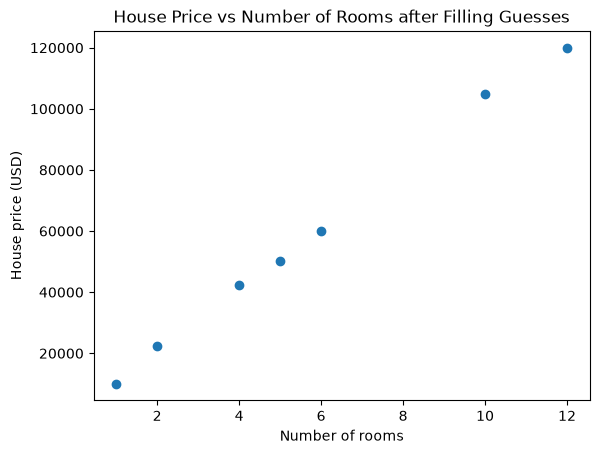

In [17]:
# Bonus attempt: sample possible guesses only
House_prices_guess = [10050, 42300, 50206, 60000, 105000, 120000, 22350]
Num_rooms_guess = [1, 4, 5, 6, 10, 12, 2]

plt.scatter(Num_rooms_guess, House_prices_guess)
plt.xlabel("Number of rooms")
plt.ylabel("House price (USD)")
plt.title("House Price vs Number of Rooms after Filling Guesses")
plt.show()

## 2.2 Handling missing values in DataFrames

Now we will work with another CSV file called `Students_Score2.csv`.

This file contains student exam results and study hours, but some students did not report their study hours or scores.

> **Goal:** Remove the missing values and report how many students had missing data.

First, load the data as a DataFrame called `df`.

In [18]:
df = pd.read_csv("./data/Students_Score2.csv")
df.head()

,Student No.,Hours spent studying in a day,Mathematics score,English score,Science score
0,1,0.0,0.0,0.0,0.0
1,2,3.0,15.0,12.9,12.6
2,3,2.0,10.0,8.6,8.4
3,4,13.0,65.0,55.9,54.6
4,5,0.0,0.0,0.0,0.0


Print the headers, first 5 rows, and `.info()` output.

In [19]:
print(df.columns)
print(df.head())
df.info()

Index(['Student No.', 'Hours spent studying in a day', 'Mathematics score',
       'English score', 'Science score'],
      dtype='str')
   Student No.  Hours spent studying in a day  Mathematics score  \
0            1                            0.0                0.0   
1            2                            3.0               15.0   
2            3                            2.0               10.0   
3            4                           13.0               65.0   
4            5                            0.0                0.0   

   English score  Science score  
0            0.0            0.0  
1           12.9           12.6  
2            8.6            8.4  
3           55.9           54.6  
4            0.0            0.0  
<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    3

From the `.info()` output, you should observe that different columns have different numbers of non-null values. This means some columns contain missing values.

Before removing missing values, we should check for erroneous data first. Use `.describe()` and observe the minimum and maximum values.

In [20]:
df.describe()

,Student No.,Hours spent studying in a day,Mathematics score,English score,Science score
count,387.000000,382.000000,383.000000,382.000000,383.000000
mean,194.000000,7.083770,35.417755,30.392670,29.641253
std,111.861522,4.473697,22.271713,19.258215,18.783876
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,97.500000,3.000000,15.000000,12.900000,12.600000
50%,194.000000,7.000000,35.000000,30.100000,29.400000
75%,290.500000,11.000000,55.000000,47.300000,46.200000
max,387.000000,15.000000,75.000000,64.500000,63.000000


You should see that the study hours are within 0 to 15 and all scores are between 0 and 100. This suggests that this dataset has missing values, but no obvious erroneous values.

Now let us remove missing values. Pandas provides a useful function called `.dropna()`.

- `df.dropna(axis=0)` removes rows with missing values
- `df.dropna(axis=1)` removes columns with missing values

For this dataset, think carefully: should we remove missing values by rows or by columns?

In [21]:
# Reference answer:
# We should use axis=0 to remove rows with missing values.
# Removing columns would remove entire score/study-hour columns, which loses too much information.


Write the code to remove missing values below. Assign the result to a new DataFrame called `df2` so that the original DataFrame is not changed.

> **Hint:** Use `df2 = df.dropna(axis=____)`

In [22]:
df2 = df.dropna(axis=0)
df2.head()

,Student No.,Hours spent studying in a day,Mathematics score,English score,Science score
0,1,0.0,0.0,0.0,0.0
1,2,3.0,15.0,12.9,12.6
2,3,2.0,10.0,8.6,8.4
3,4,13.0,65.0,55.9,54.6
4,5,0.0,0.0,0.0,0.0


Print `.info()` for the new DataFrame and observe the number of non-null values for each column.

In [23]:
df2.info()

<class 'pandas.DataFrame'>
Index: 373 entries, 0 to 386
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    373 non-null    int64  
 1   Hours spent studying in a day  373 non-null    float64
 2   Mathematics score              373 non-null    float64
 3   English score                  373 non-null    float64
 4   Science score                  373 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 17.5 KB


Do you see that the number of rows is now the same for all columns? How many students had missing values?

> **Hint:** Compare the number of rows before and after `.dropna()`.

In [24]:
# Calculate how many rows were removed
original_rows = len(df)
cleaned_rows = len(df2)
missing_rows = original_rows - cleaned_rows

print("Original rows:", original_rows)
print("Rows after removing missing values:", cleaned_rows)
print("Rows with missing data:", missing_rows)

Original rows: 387
Rows after removing missing values: 373
Rows with missing data: 14


**Bonus:** Sometimes we do not want to remove missing values, especially if the dataset is small. Another approach is to fill missing values using a suitable value, such as the average.

Run the example below. It fills missing values in the `Mathematics score` column using the mean Mathematics score.

In [25]:
# The .copy() allows us to copy the whole dataframe so we do not change the original dataframe
df3 = df.copy()

print("Before filling in missing values..........")
print(df3.info())

df3["Mathematics score"] = df3["Mathematics score"].fillna(df["Mathematics score"].mean())

print("After filling in missing values..........")
print(df3.info())

Before filling in missing values..........
<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    387 non-null    int64  
 1   Hours spent studying in a day  382 non-null    float64
 2   Mathematics score              383 non-null    float64
 3   English score                  382 non-null    float64
 4   Science score                  383 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 15.2 KB
None
After filling in missing values..........
<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    387 non-null    int64  
 1   Hours spent studying in a day  382 non-null    float64
 2   Mathemat

You should now see that the missing values for Mathematics score have been filled in.

Now try to fill in the missing values for the rest of the columns using their respective averages.

In [26]:
df3["Hours spent studying in a day"] = df3["Hours spent studying in a day"].fillna(df["Hours spent studying in a day"].mean())
df3["English score"] = df3["English score"].fillna(df["English score"].mean())
df3["Science score"] = df3["Science score"].fillna(df["Science score"].mean())

df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student No.                    387 non-null    int64  
 1   Hours spent studying in a day  387 non-null    float64
 2   Mathematics score              387 non-null    float64
 3   English score                  387 non-null    float64
 4   Science score                  387 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 15.2 KB


## Recap

In this notebook, you practised how to:

- distinguish erroneous data, outliers, and missing data
- remove impossible or unrealistic values
- inspect a dataset using `.head()`, `.info()`, and `.describe()`
- remove missing values using `.dropna()`
- fill missing values using `.fillna()`

These steps are important because machine learning models can produce poor results if the data contains wrong or missing values.